In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.10.1
NumPy: 1.23.5
OpenCV: 4.8.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("..").resolve()

possible_data_roots = [
    PROJECT_ROOT / "data" / "raw" / "state_farm",
    PROJECT_ROOT / "state-farm-distracted-driver-detection",
]

DATA_ROOT = None

for path in possible_data_roots:
    if (path / "driver_imgs_list.csv").exists():
        DATA_ROOT = path
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find driver_imgs_list.csv. "
        "Please check your State Farm dataset folder."
    )

TRAIN_IMG_DIR = DATA_ROOT / "imgs" / "train"
TEST_IMG_DIR = DATA_ROOT / "imgs" / "test"
CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("CSV exists:", CSV_PATH.exists())
print("Train image folder exists:", TRAIN_IMG_DIR.exists())
print("Test image folder exists:", TEST_IMG_DIR.exists())

Project root: D:\MSC_PROJECT
Dataset root: D:\MSC_PROJECT\state-farm-distracted-driver-detection
CSV exists: True
Train image folder exists: True
Test image folder exists: True


In [3]:
df = pd.read_csv(CSV_PATH)

print("First 5 rows:")
display(df.head())

print("Dataset information:")
display(df.info())

print("Total labelled images:", len(df))
print("Number of drivers/subjects:", df["subject"].nunique())
print("Classes:", sorted(df["classname"].unique()))

First 5 rows:


,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22424 entries, 0 to 22423
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   subject    22424 non-null  object
 1   classname  22424 non-null  object
 2   img        22424 non-null  object
dtypes: object(3)
memory usage: 525.7+ KB


None

Total labelled images: 22424
Number of drivers/subjects: 26
Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']


In [4]:
CLASS_NAMES = {
    "c0": "safe driving",
    "c1": "texting right",
    "c2": "talking on the phone right",
    "c3": "texting left",
    "c4": "talking on the phone left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

CLASS_ORDER = [f"c{i}" for i in range(10)]

for class_id in CLASS_ORDER:
    print(class_id, "=", CLASS_NAMES[class_id])

c0 = safe driving
c1 = texting right
c2 = talking on the phone right
c3 = texting left
c4 = talking on the phone left
c5 = operating the radio
c6 = drinking
c7 = reaching behind
c8 = hair and makeup
c9 = talking to passenger


In [5]:
df["filepath"] = df.apply(
    lambda row: str(TRAIN_IMG_DIR / row["classname"] / row["img"]),
    axis=1
)

df["file_exists"] = df["filepath"].apply(lambda path: Path(path).exists())

print("Total rows:", len(df))
print("Existing image files:", df["file_exists"].sum())
print("Missing image files:", (~df["file_exists"]).sum())

display(df.head())

Total rows: 22424
Existing image files: 22424
Missing image files: 0


,subject,classname,img,filepath,file_exists
0,p002,c0,img_44733.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True
1,p002,c0,img_72999.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True
2,p002,c0,img_25094.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True
3,p002,c0,img_69092.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True
4,p002,c0,img_92629.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True


In [6]:
df = df[df["file_exists"]].reset_index(drop=True)

print("Clean dataset size:", len(df))

Clean dataset size: 22424


In [7]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures folder:", FIGURES_DIR)
print("Tables folder:", TABLES_DIR)

Figures folder: D:\MSC_PROJECT\results\figures
Tables folder: D:\MSC_PROJECT\results\tables


In [8]:
class_counts = df["classname"].value_counts().sort_index()
class_counts_named = class_counts.rename(index=CLASS_NAMES)

display(class_counts_named)

classname
safe driving                  2489
texting right                 2267
talking on the phone right    2317
texting left                  2346
talking on the phone left     2326
operating the radio           2312
drinking                      2325
reaching behind               2002
hair and makeup               1911
talking to passenger          2129
Name: count, dtype: int64

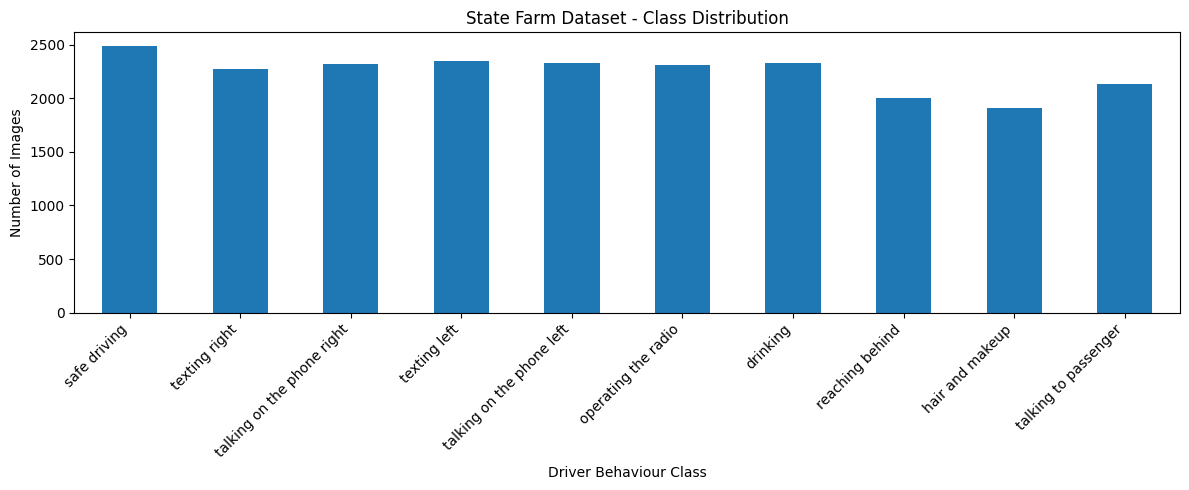

In [9]:
plt.figure(figsize=(12, 5))

class_counts_named.plot(kind="bar")

plt.title("State Farm Dataset - Class Distribution")
plt.xlabel("Driver Behaviour Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "state_farm_class_distribution.png", dpi=300)
plt.show()

In [10]:
class_distribution_table = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [CLASS_NAMES[c] for c in class_counts.index],
    "image_count": class_counts.values
})

display(class_distribution_table)

class_distribution_table.to_csv(
    TABLES_DIR / "state_farm_class_distribution.csv",
    index=False
)

print("Saved class distribution table.")

,class_id,class_name,image_count
0,c0,safe driving,2489
1,c1,texting right,2267
2,c2,talking on the phone right,2317
3,c3,texting left,2346
4,c4,talking on the phone left,2326
5,c5,operating the radio,2312
6,c6,drinking,2325
7,c7,reaching behind,2002
8,c8,hair and makeup,1911
9,c9,talking to passenger,2129


Saved class distribution table.


In [11]:
subject_counts = df["subject"].value_counts().sort_values(ascending=False)

print("Number of unique subjects:", len(subject_counts))
display(subject_counts.head(10))

Number of unique subjects: 26


subject
p021    1237
p022    1233
p024    1226
p026    1196
p016    1078
p066    1034
p049    1011
p051     920
p014     876
p015     875
Name: count, dtype: int64

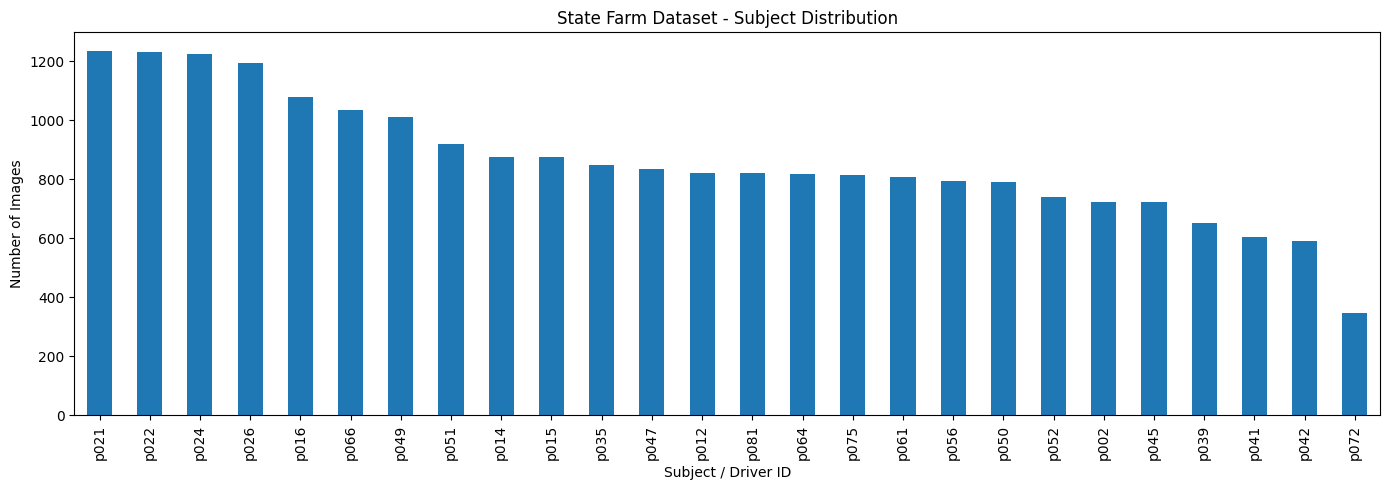

In [12]:
plt.figure(figsize=(14, 5))

subject_counts.plot(kind="bar")

plt.title("State Farm Dataset - Subject Distribution")
plt.xlabel("Subject / Driver ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "state_farm_subject_distribution.png", dpi=300)
plt.show()

In [13]:
subject_distribution_table = subject_counts.reset_index()
subject_distribution_table.columns = ["subject", "image_count"]

display(subject_distribution_table.head())

subject_distribution_table.to_csv(
    TABLES_DIR / "state_farm_subject_distribution.csv",
    index=False
)

print("Saved subject distribution table.")

,subject,image_count
0,p021,1237
1,p022,1233
2,p024,1226
3,p026,1196
4,p016,1078


Saved subject distribution table.


C:\Users\dulha\AppData\Local\Temp\ipykernel_1424\4146346401.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=42))


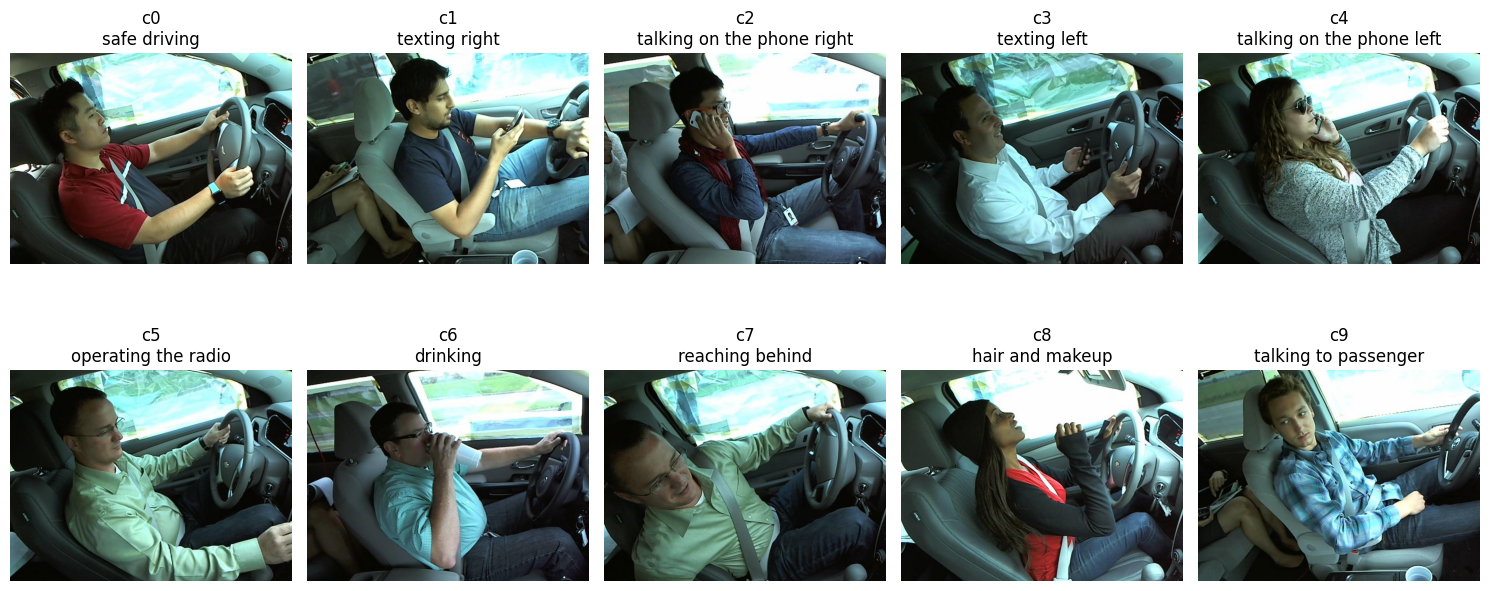

In [14]:
sample_df = (
    df.groupby("classname", group_keys=False)
    .apply(lambda x: x.sample(1, random_state=42))
    .sort_values("classname")
)

plt.figure(figsize=(15, 7))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    image = Image.open(row["filepath"])

    plt.subplot(2, 5, i)
    plt.imshow(image)
    plt.title(f"{row['classname']}\n{CLASS_NAMES[row['classname']]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "state_farm_sample_images.png", dpi=300)
plt.show()

In [15]:
sample_paths = df["filepath"].sample(100, random_state=42)

image_sizes = []

for path in sample_paths:
    image = Image.open(path)
    image_sizes.append(image.size)

image_size_df = pd.DataFrame(image_sizes, columns=["width", "height"])

display(image_size_df.describe())

print("Most common image sizes:")
display(image_size_df.value_counts().head())

,width,height
count,100.0,100.0
mean,640.0,480.0
std,0.0,0.0
min,640.0,480.0
25%,640.0,480.0
50%,640.0,480.0
75%,640.0,480.0
max,640.0,480.0


Most common image sizes:


width  height
640    480       100
Name: count, dtype: int64

In [16]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

clean_metadata_path = PROCESSED_DIR / "state_farm_clean_metadata.csv"

df.to_csv(clean_metadata_path, index=False)

print("Saved cleaned metadata to:")
print(clean_metadata_path)

Saved cleaned metadata to:
D:\MSC_PROJECT\data\processed\state_farm_clean_metadata.csv


In [17]:
summary = {
    "dataset_root": str(DATA_ROOT),
    "total_images": len(df),
    "unique_subjects": df["subject"].nunique(),
    "number_of_classes": df["classname"].nunique(),
    "classes": sorted(df["classname"].unique()),
}

summary

{'dataset_root': 'D:\\MSC_PROJECT\\state-farm-distracted-driver-detection',
 'total_images': 22424,
 'unique_subjects': 26,
 'number_of_classes': 10,
 'classes': ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']}